Original  - Mean: 20.22, Std: 8.77
Scaled    - Mean: 0.0000,  Std: 1.0000
Scaled Coefficient: 0.9357
Intercept:          3.0878

MAE  : 0.6209
MSE  : 0.5688
RMSE : 0.7542
R²   : 0.5449


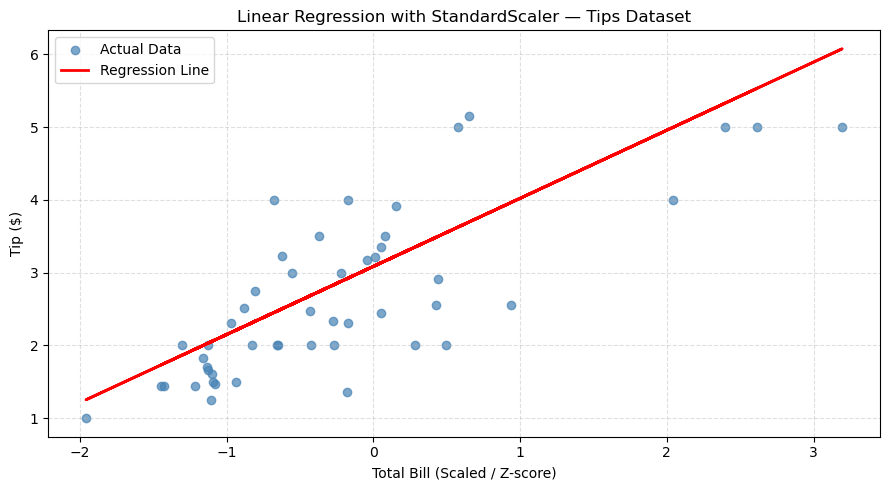

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler          # NEW: import scaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Step 1: Load Data ──────────────────────────────────────────────
tips = sns.load_dataset('tips')
X = tips[['total_bill']]
y = tips['tip']

# ── Step 2: Train-Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Step 3: Scale the Features ────────────────────────────────────
scaler = StandardScaler()

# IMPORTANT RULE:
# Fit ONLY on training data → learn mean & std from train set
# Then transform BOTH train and test using those same values
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)         # transform test only (NO fit!)

# See what scaling did
print(f"Original  - Mean: {X_train['total_bill'].mean():.2f}, Std: {X_train['total_bill'].std():.2f}")
print(f"Scaled    - Mean: {X_train_scaled.mean():.4f},  Std: {X_train_scaled.std():.4f}")
# Output:
# Original  - Mean: 19.79,  Std: 8.83
# Scaled    - Mean: 0.0000, Std: 1.0000   ✅

# ── Step 4: Train Model on Scaled Data ────────────────────────────
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"Scaled Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept:          {model.intercept_:.4f}")
# The coefficient is now in "standard deviation units", not dollars

# ── Step 5: Predict ───────────────────────────────────────────────
y_pred = model.predict(X_test_scaled)

# ── Step 6: Metrics ───────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"\nMAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ── Step 7: Plot Regression Line ──────────────────────────────────
plt.figure(figsize=(9, 5))
plt.scatter(X_test_scaled, y_test, color='steelblue', alpha=0.7, label='Actual Data')
plt.plot(X_test_scaled, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression with StandardScaler — Tips Dataset')
plt.xlabel('Total Bill (Scaled / Z-score)')
plt.ylabel('Tip ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()